# Part A: Machine Learning - Insurance Claim Prediction

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported!')

Libraries imported!


# TASK 1: Dataset Understanding

In [18]:
df = pd.read_csv('insurance2.csv')
print(f'Shape: {df.shape}')
print('\nFirst 5 records:')
print(df.head())

Shape: (1338, 8)

First 5 records:
   age  sex     bmi  children  smoker  region      charges  insuranceclaim
0   19    0  27.900         0       1       3  16884.92400               1
1   18    1  33.770         1       0       2   1725.55230               1
2   28    1  33.000         3       0       2   4449.46200               0
3   33    1  22.705         0       0       1  21984.47061               0
4   32    1  28.880         0       0       1   3866.85520               1


In [19]:
print('Last 5 records:')
print(df.tail())

Last 5 records:
      age  sex    bmi  children  smoker  region     charges  insuranceclaim
1333   50    1  30.97         3       0       1  10600.5483               0
1334   18    0  31.92         0       0       0   2205.9808               1
1335   18    0  36.85         0       0       2   1629.8335               1
1336   21    0  25.80         0       0       3   2007.9450               0
1337   61    0  29.07         0       1       1  29141.3603               1


In [20]:
print('Columns:', df.columns.tolist())
print('Data types:')
print(df.dtypes)

Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'insuranceclaim']
Data types:
age                 int64
sex                 int64
bmi               float64
children            int64
smoker              int64
region              int64
charges           float64
insuranceclaim      int64
dtype: object


In [21]:
print('Missing values:', df.isnull().sum().sum())
print('\nNumerical:', df.select_dtypes(include=['int64', 'float64']).columns.tolist())
print('Categorical:', df.select_dtypes(include=['object']).columns.tolist())

Missing values: 0

Numerical: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'insuranceclaim']
Categorical: []


In [22]:
print('Target (insuranceclaim) distribution:')
print(df['insuranceclaim'].value_counts())
print('\nPercentages:')
print((df['insuranceclaim'].value_counts() / len(df) * 100).round(2))

Target (insuranceclaim) distribution:
insuranceclaim
1    783
0    555
Name: count, dtype: int64

Percentages:
insuranceclaim
1    58.52
0    41.48
Name: count, dtype: float64


# TASK 2: Exploratory Data Analysis

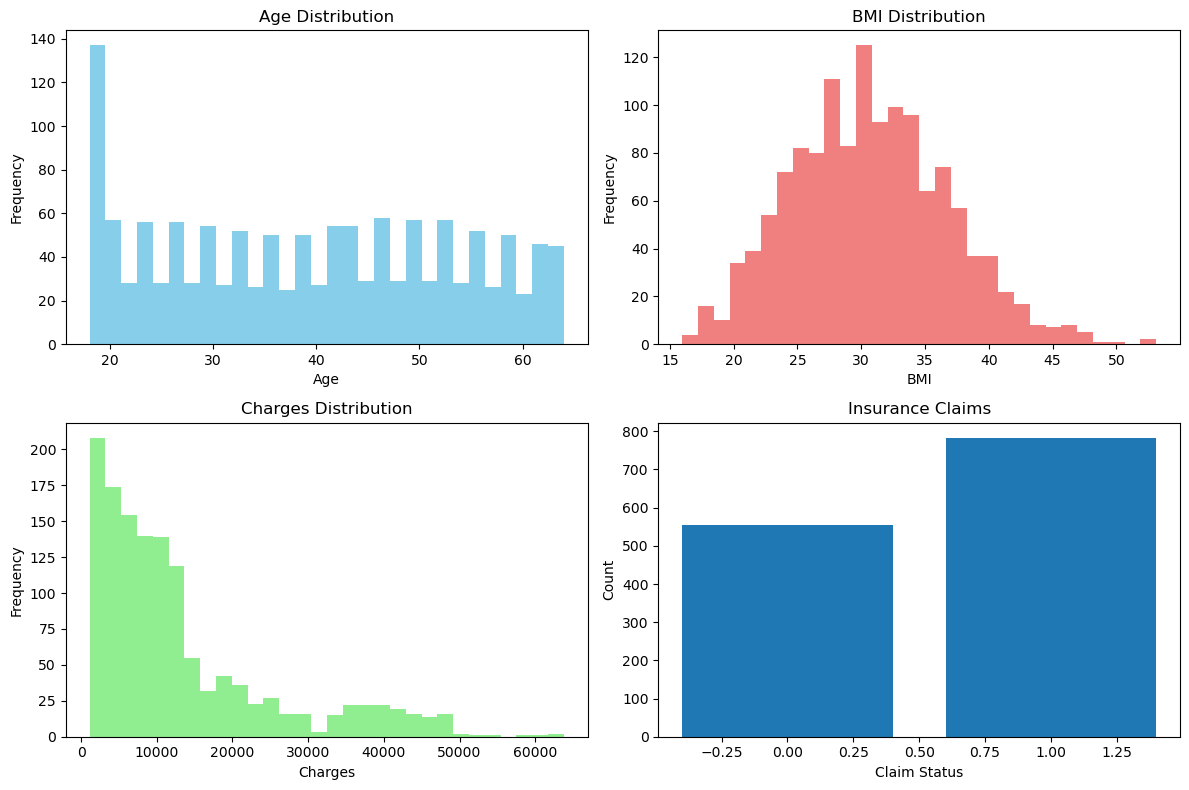

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].hist(df['age'], bins=30, color='skyblue')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Frequency')
axes[0,1].hist(df['bmi'], bins=30, color='lightcoral')
axes[0,1].set_title('BMI Distribution')
axes[0,1].set_xlabel('BMI')
axes[0,1].set_ylabel('Frequency')
axes[1,0].hist(df['charges'], bins=30, color='lightgreen')
axes[1,0].set_title('Charges Distribution')
axes[1,0].set_xlabel('Charges')
axes[1,0].set_ylabel('Frequency')
axes[1,1].bar(df['insuranceclaim'].value_counts().index, df['insuranceclaim'].value_counts().values)
axes[1,1].set_title('Insurance Claims')
axes[1,1].set_xlabel('Claim Status')
axes[1,1].set_ylabel('Count')
plt.tight_layout()
plt.show()

# TASK 3: Data Preprocessing

In [24]:
X = df.drop('insuranceclaim', axis=1)
y = df['insuranceclaim']
print(f'X shape: {X.shape}, y shape: {y.shape}')

X shape: (1338, 7), y shape: (1338,)


In [33]:
# X_processed = X.copy()
# categorical_cols = X_processed.select_dtypes(include=['object']).columns.tolist()
# label_encoders = {}
# for col in categorical_cols:
#     le = LabelEncoder()
#     X_processed[col] = le.fit_transform(X_processed[col])
#     label_encoders[col] = le
# print('Encoding complete')

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.3, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} (70%), Test: {len(X_test)} (30%)')

Train: 936 (70%), Test: 402 (30%)


In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
print('Scaling complete - fit on training data only to prevent data leakage')
print(X_train_scaled.head)

Scaling complete - fit on training data only to prevent data leakage
<bound method NDFrame.head of           age       sex       bmi  children    smoker    region   charges
0    0.499404  0.980951 -0.663812 -0.068199 -0.497996  0.469546 -0.451054
1   -0.284775 -1.019419  0.574560 -0.068199 -0.497996  0.469546 -0.663778
2    1.711317  0.980951  1.486615  1.568587 -0.497996  1.366475  0.181779
3   -1.496689  0.980951 -1.256077 -0.886593 -0.497996 -1.324311 -0.965428
4   -0.070908 -1.019419  1.543721 -0.886593 -0.497996  0.469546 -0.650508
..        ...       ...       ...       ...       ...       ...       ...
931 -1.211532 -1.019419 -0.304864 -0.886593 -0.497996  0.469546 -0.926904
932  1.283583 -1.019419 -0.807392  0.750194 -0.497996  0.469546 -0.034696
933 -0.926376  0.980951  0.526428 -0.068199 -0.497996 -0.427383 -0.830140
934 -1.496689 -1.019419  1.077088 -0.068199 -0.497996  0.469546 -0.921563
935 -0.855087  0.980951  2.481881  0.750194 -0.497996  1.366475 -0.795985

[936 rows x 

# TASK 4: Build ML Models

In [28]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print('Logistic Regression Accuracy:', round(lr_accuracy, 4))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8781
              precision    recall  f1-score   support

           0       0.86      0.84      0.85       167
           1       0.89      0.90      0.90       235

    accuracy                           0.88       402
   macro avg       0.88      0.87      0.87       402
weighted avg       0.88      0.88      0.88       402



In [29]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print('Random Forest Accuracy:', round(rf_accuracy, 4))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9378
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       167
           1       0.95      0.94      0.95       235

    accuracy                           0.94       402
   macro avg       0.94      0.94      0.94       402
weighted avg       0.94      0.94      0.94       402



# TASK 5: Model Evaluation

In [30]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_accuracy, rf_accuracy]
})
print(comparison)
print(f'\nBest: {"Random Forest" if rf_accuracy > lr_accuracy else "Logistic Regression"}')

                 Model  Accuracy
0  Logistic Regression  0.878109
1        Random Forest  0.937811

Best: Random Forest


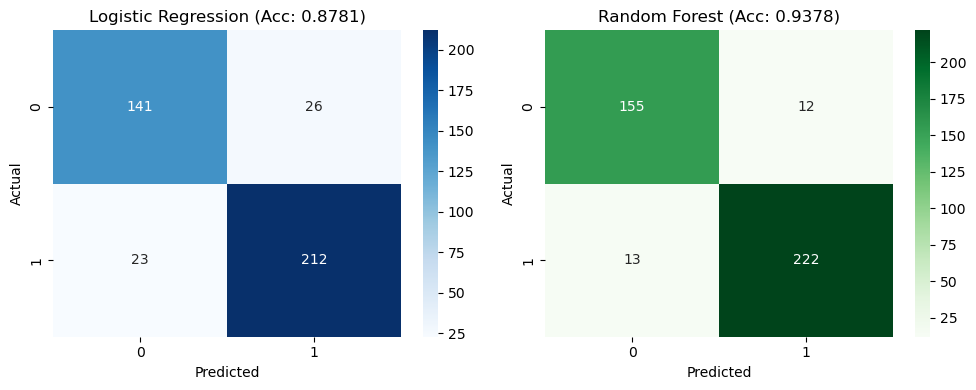

In [31]:
from sklearn.metrics import confusion_matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Logistic Regression (Acc: {lr_accuracy:.4f})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Random Forest (Acc: {rf_accuracy:.4f})')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()

    Feature  Importance
2       bmi    0.354015
3  children    0.257819
6   charges    0.170508
0       age    0.101690
4    smoker    0.079276
5    region    0.025664
1       sex    0.011027


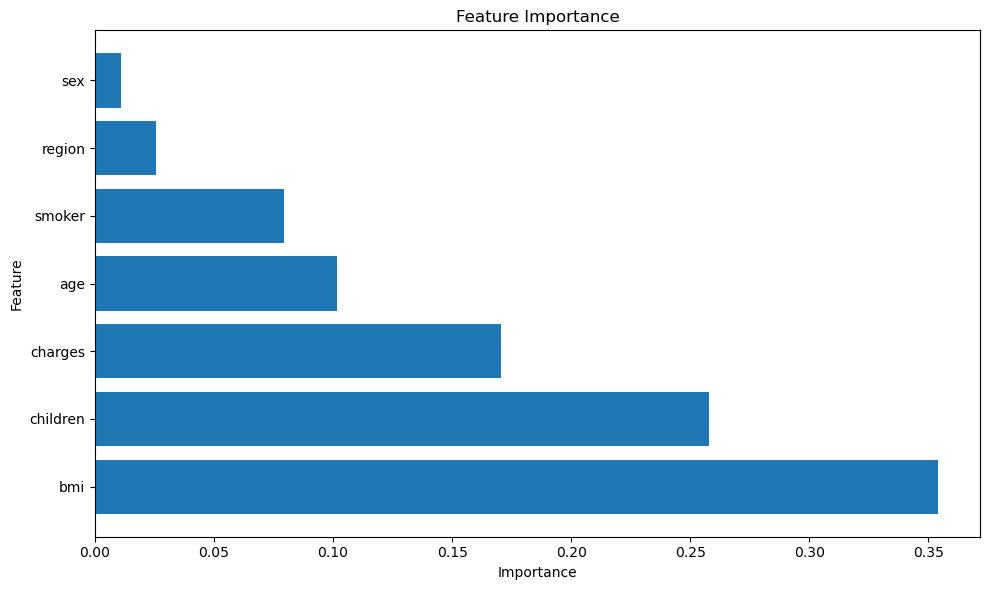

In [32]:
feat_imp = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
print(feat_imp)
plt.figure(figsize=(10, 6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()